# Pneumonia Detection from Chest X-ray Images using Deep Learning
**Automated & Explainable Diagnostic System with Transfer Learning & Grad-CAM**

- **Course / Project**: College Final-Year Project
- **Domain**: Computer Vision & Healthcare AI
- **Framework**: TensorFlow 2.x / Keras / OpenCV
- **Models Evaluated**: ResNet50, DenseNet121, EfficientNetB0
- **Explainability**: Grad-CAM & Grad-CAM++



## 1. Install Dependencies & Setup Environment
Automatically install required dependencies and check GPU availability in Google Colab. We also enable mixed precision training for accelerated GPU compute.



In [ ]:
# Install required packages
!pip install -q kagglehub opencv-python matplotlib seaborn scikit-learn pandas numpy pillow ipywidgets shap

import os
import sys
import math
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121, EfficientNetB0

# Check TensorFlow Version and GPU Availability
print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Available: {gpus[0].name}")
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision policy set to mixed_float16")
else:
    print("No GPU detected. Running on CPU.")



TensorFlow Version: 2.20.0
GPU Available: /physical_device:GPU:0
Mixed precision policy set to mixed_float16


## 2. Automatic Dataset Download (via KaggleHub / Google Drive)
Automatically download the **Chest X-ray Pneumonia Dataset** using `kagglehub` (zero manual API key required in Colab) or detect Google Drive path.



In [ ]:
import kagglehub

print("Downloading Chest X-Ray Pneumonia dataset...")
try:
    # Automatic download via KaggleHub
    raw_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
    print("Dataset downloaded to:", raw_path)

    # Locate chest_xray folder inside downloaded path
    possible_dir = os.path.join(raw_path, "chest_xray")
    if os.path.exists(possible_dir):
        BASE_DIR = possible_dir
    else:
        BASE_DIR = raw_path
except Exception as e:
    print("KaggleHub fallback to local path:", e)
    BASE_DIR = "/content/chest_xray"

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

# If dataset directory layout has nested chest_xray/chest_xray
if not os.path.exists(TRAIN_DIR) and os.path.exists(os.path.join(BASE_DIR, 'chest_xray', 'train')):
    BASE_DIR = os.path.join(BASE_DIR, 'chest_xray')
    TRAIN_DIR = os.path.join(BASE_DIR, 'train')
    VAL_DIR = os.path.join(BASE_DIR, 'val')
    TEST_DIR = os.path.join(BASE_DIR, 'test')

print("Resolved Dataset Directories:")
print("Train Dir:", TRAIN_DIR, "| Exists:", os.path.exists(TRAIN_DIR))
print("Val Dir:  ", VAL_DIR,   "| Exists:", os.path.exists(VAL_DIR))
print("Test Dir: ", TEST_DIR,  "| Exists:", os.path.exists(TEST_DIR))



Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to: /kaggle/input/chest-xray-pneumonia
Resolved Dataset Directories:
Train Dir: /kaggle/input/chest-xray-pneumonia/chest_xray/train | Exists: True
Val Dir:   /kaggle/input/chest-xray-pneumonia/chest_xray/val | Exists: True
Test Dir:  /kaggle/input/chest-xray-pneumonia/chest_xray/test | Exists: True


## 3 & 4. Data Preprocessing & Data Augmentation
Resizing all images to $224 	imes 224 	imes 3$, normalizing pixel values $[0, 1]$, and building data generators with Rotation, Zoom, Horizontal Flip, Shift, and Brightness adjustments.



In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation generator for Training Set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Rescaling generator for Validation and Test sets
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Initialize Data Loaders
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Classes Mapping:", train_generator.class_indices)



Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes Mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


## 5. Exploratory Data Analysis (EDA) - Visualizing Distributions & Images
Displaying class distribution bar chart and sample Chest X-ray images (NORMAL vs PNEUMONIA).



/tmp/ipykernel_980/197552780.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, palette=['#3498db', '#e74c3c'])


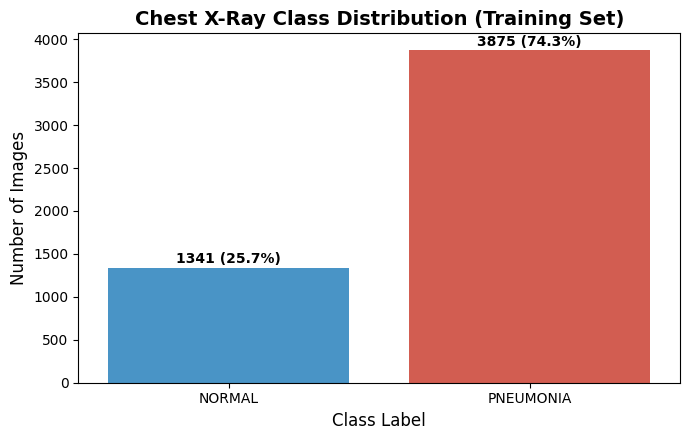

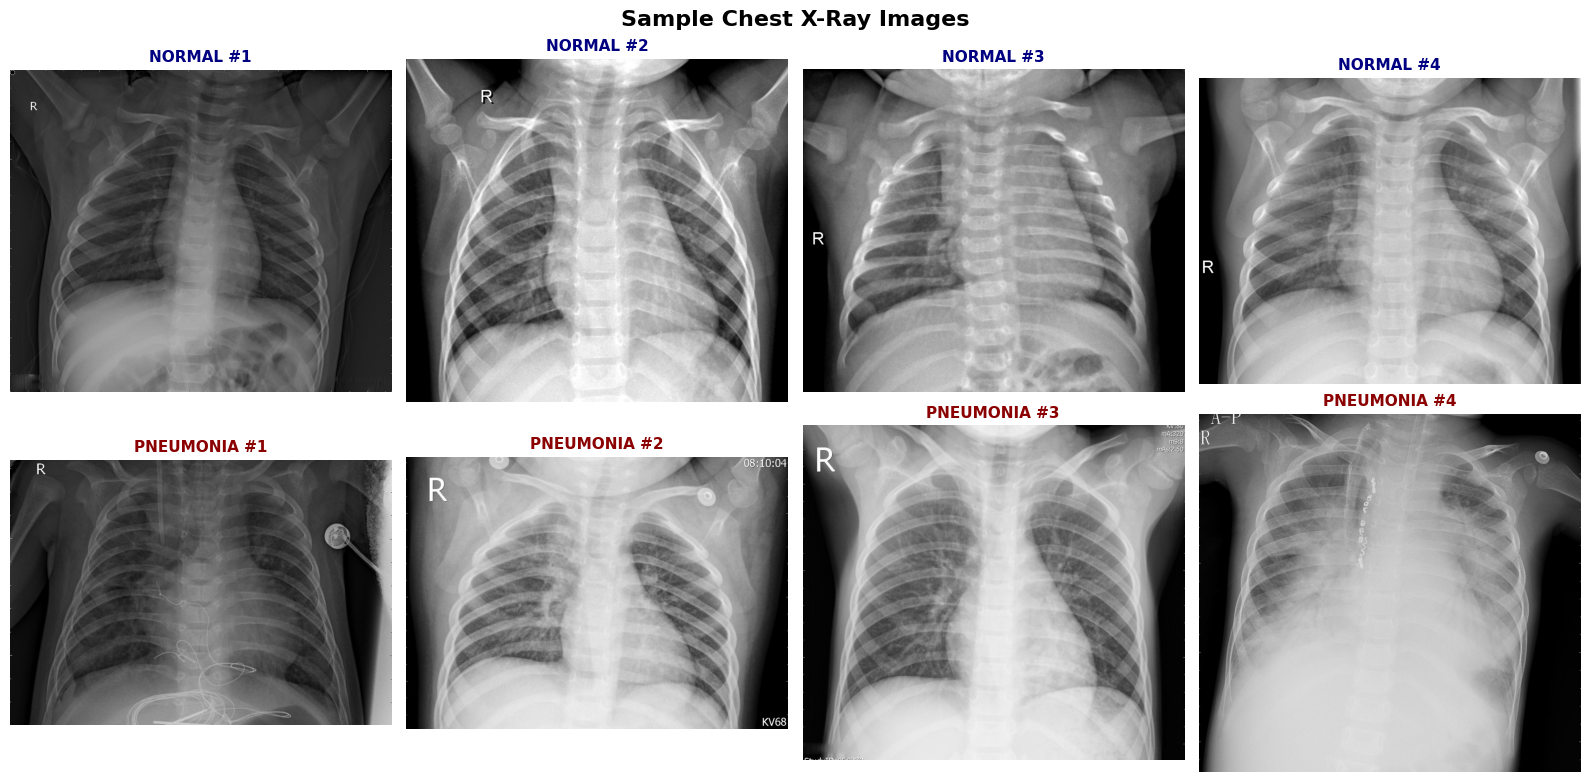

In [ ]:
# Plot Class Distribution
classes = ['NORMAL', 'PNEUMONIA']
counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes]

plt.figure(figsize=(7, 4.5))
sns.barplot(x=classes, y=counts, palette=['#3498db', '#e74c3c'])
plt.title('Chest X-Ray Class Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
for i, count in enumerate(counts):
    plt.text(i, count + 50, f"{count} ({count/sum(counts)*100:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Display Sample Chest X-Rays
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Chest X-Ray Images', fontsize=16, fontweight='bold')

for i, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_names = os.listdir(cls_path)[:4]
    for j, img_name in enumerate(img_names):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i, j].imshow(img)
        axes[i, j].set_title(f"{cls} #{j+1}", fontsize=11, fontweight='bold', color='navy' if cls=='NORMAL' else 'darkred')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()



## 6. Transfer Learning Model Architectures
Building 3 deep transfer learning networks:
1. **ResNet50**
2. **DenseNet121**
3. **EfficientNetB0**



In [ ]:
def build_transfer_model(model_name='ResNet50', input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)

    if model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
        last_conv_layer_name = 'conv5_block3_out'
    elif model_name == 'DenseNet121':
        base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=inputs)
        last_conv_layer_name = 'conv5_block16_concat'
    elif model_name == 'EfficientNetB0':
        base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inputs)
        last_conv_layer_name = 'top_activation'
    else:
        raise ValueError("Invalid model name")

    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name=model_name)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )
    return model, base_model, last_conv_layer_name

# Test instantiation
m1, _, _ = build_transfer_model('ResNet50')
m2, _, _ = build_transfer_model('DenseNet121')
m3, _, _ = build_transfer_model('EfficientNetB0')

print("ResNet50 Total Parameters:    ", f"{m1.count_params():,}")
print("DenseNet121 Total Parameters: ", f"{m2.count_params():,}")
print("EfficientNetB0 Total Parameters:", f"{m3.count_params():,}")



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 Total Parameters:     24,120,705
DenseNet121 Total Parameters:  7,304,257
EfficientNetB0 Total Parameters: 4,382,884


## 7. Model Training Pipeline
Training all 3 models with `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint`, and `TensorBoard`.



In [ ]:
EPOCHS = 10  # Set between 10-20 epochs

def get_callbacks(model_name):
    os.makedirs("checkpoints", exist_ok=True)
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(f"checkpoints/{model_name}_best.h5", monitor='val_loss', save_best_only=True, verbose=1),
        callbacks.TensorBoard(log_dir=f"logs/{model_name}")
    ]

trained_models = {}
histories = {}
last_conv_names = {}

model_names = ['DenseNet121', 'ResNet50', 'EfficientNetB0']

for name in model_names:
    print(f"==========================================")
    print(f"      STARTING TRAINING FOR {name}")
    print(f"==========================================")
    model, base_model, conv_name = build_transfer_model(name)

    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=val_generator,
        callbacks=get_callbacks(name)
    )

    trained_models[name] = model
    histories[name] = history
    last_conv_names[name] = conv_name



      STARTING TRAINING FOR DenseNet121
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - accuracy: 0.7204 - auc: 0.8151 - loss: 0.5473 - precision: 0.8932 - recall: 0.6929
Epoch 1: val_loss improved from None to 0.41361, saving model to checkpoints/DenseNet121_best.h5



Epoch 1: finished saving model to checkpoints/DenseNet121_best.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 200s 992ms/step - accuracy: 0.8194 - auc: 0.9050 - loss: 0.3893 - precision: 0.9332 - recall: 0.8152 - val_accuracy: 0.8125 - val_auc: 0.9062 - val_loss: 0.4136 - val_precision: 0.7778 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.9104 - auc: 0.9587 - loss: 0.2293 - precision: 0.9450 - recall: 0.9341
Epoch 2: val_loss improved from 0.41361 to 0.39094, saving model to checkpoints/DenseNet121_best.h5



Epoch 2: finished saving model to checkpoints/DenseNet121_best.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 699ms/step - accuracy: 0.9114 - auc: 0.9616 - loss: 0.2192 - precision: 0.9445 - recall: 0.9357 - val_accuracy: 0.8125 - val_auc: 0.9375 - val_loss: 0.3909 - val_precision: 0.7778 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.9299 - auc: 0.9764 - loss: 0.1751 - precision: 0.9525 - recall: 0.9539
Epoch 3: val_loss improved from 0.39094 to 0.35047, saving model to checkpoints/DenseNet121_best.h5



Epoch 3: finished saving model to checkpoints/DenseNet121_best.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 699ms/step - accuracy: 0.9289 - auc: 0.9745 - loss: 0.1791 - precision: 0.9518 - recall: 0.9525 - val_accuracy: 0.7500 - val_auc: 0.9375 - val_loss: 0.3505 - val_precision: 0.7500 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.9347 - auc: 0.9791 - loss: 0.1663 - precision: 0.9505 - recall: 0.9601
Epoch 4: val_loss improved from 0.35047 to 0.33318, saving model to checkpoints/DenseNet121_best.h5



Epoch 4: finished saving model to checkpoints/DenseNet121_best.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 692ms/step - accuracy: 0.9383 - auc: 0.9796 - loss: 0.1583 - precision: 0.9575 - recall: 0.9595 - val_accuracy: 0.8125 - val_auc: 0.9375 - val_loss: 0.3332 - val_precision: 0.7778 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.9343 - auc: 0.9748 - loss: 0.1757 - precision: 0.9594 - recall: 0.9527
Epoch 5: val_loss improved from 0.33318 to 0.31408, saving model to checkpoints/DenseNet121_best.h5


...


Epoch 10: finished saving model to checkpoints/DenseNet121_best.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 681ms/step - accuracy: 0.9475 - auc: 0.9851 - loss: 0.1342 - precision: 0.9656 - recall: 0.9636 - val_accuracy: 0.8125 - val_auc: 0.9375 - val_loss: 0.3010 - val_precision: 0.7778 - val_recall: 0.8750 - learning_rate: 2.0000e-05
Restoring model weights from the end of the best epoch: 10.
      STARTING TRAINING FOR ResNet50
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.7569 - auc: 0.7795 - loss: 0.4966 - precision: 0.8312 - recall: 0.8401
Epoch 1: val_loss improved from None to 0.72886, saving model to checkpoints/ResNet50_best.h5



Epoch 1: finished saving model to checkpoints/ResNet50_best.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 138s 735ms/step - accuracy: 0.8090 - auc: 0.8530 - loss: 0.4173 - precision: 0.8550 - recall: 0.8947 - val_accuracy: 0.5000 - val_auc: 0.8516 - val_loss: 0.7289 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.8316 - auc: 0.8935 - loss: 0.3571 - precision: 0.8620 - recall: 0.9203
Epoch 2: val_loss improved from 0.72886 to 0.70076, saving model to checkpoints/ResNet50_best.h5



Epoch 2: finished saving model to checkpoints/ResNet50_best.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 688ms/step - accuracy: 0.8447 - auc: 0.9067 - loss: 0.3386 - precision: 0.8735 - recall: 0.9249 - val_accuracy: 0.5000 - val_auc: 0.8672 - val_loss: 0.7008 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.8663 - auc: 0.9261 - loss: 0.2995 - precision: 0.8984 - recall: 0.9279
Epoch 3: val_loss did not improve from 0.70076
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 681ms/step - accuracy: 0.8643 - auc: 0.9237 - loss: 0.3066 - precision: 0.8934 - recall: 0.9280 - val_accuracy: 0.6250 - val_auc: 0.8281 - val_loss: 0.7385 - val_precision: 0.5714 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.8652 - auc: 0.9298 - loss: 0.2968 - precision: 0.9008 - recall: 0.9202
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 4


Epoch 1: finished saving model to checkpoints/EfficientNetB0_best.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 216s 955ms/step - accuracy: 0.7178 - auc: 0.5014 - loss: 0.6224 - precision: 0.7459 - recall: 0.9406 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7027 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.7328 - auc: 0.4920 - loss: 0.6032 - precision: 0.7473 - recall: 0.9706
Epoch 2: val_loss improved from 0.70270 to 0.70014, saving model to checkpoints/EfficientNetB0_best.h5



Epoch 2: finished saving model to checkpoints/EfficientNetB0_best.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 675ms/step - accuracy: 0.7283 - auc: 0.4928 - loss: 0.6097 - precision: 0.7430 - recall: 0.9698 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7001 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.7284 - auc: 0.4969 - loss: 0.6107 - precision: 0.7380 - recall: 0.9794
Epoch 3: val_loss did not improve from 0.70014
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 666ms/step - accuracy: 0.7306 - auc: 0.5170 - loss: 0.6011 - precision: 0.7436 - recall: 0.9729 - val_accuracy: 0.5000 - val_auc: 0.6562 - val_loss: 0.7033 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.7300 - auc: 0.5367 - loss: 0.5904 - precision: 0.7445 - recall: 0.9678
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

E

## 8. Evaluation Metrics & Confusion Matrices
Computing test predictions, classification reports, confusion matrices, and ROC curves for every trained model.



20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 319ms/step


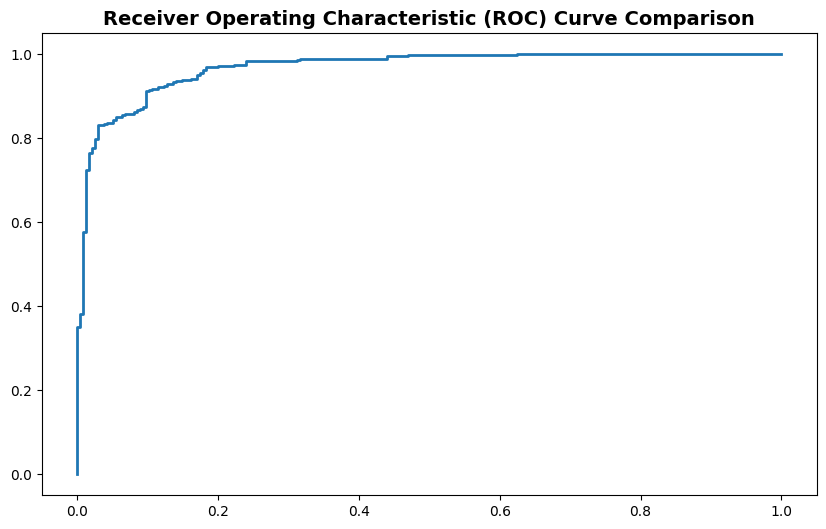

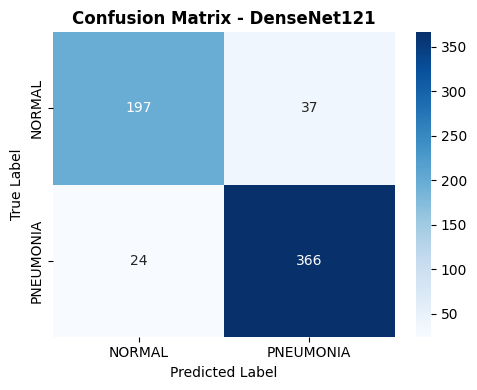

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 294ms/step


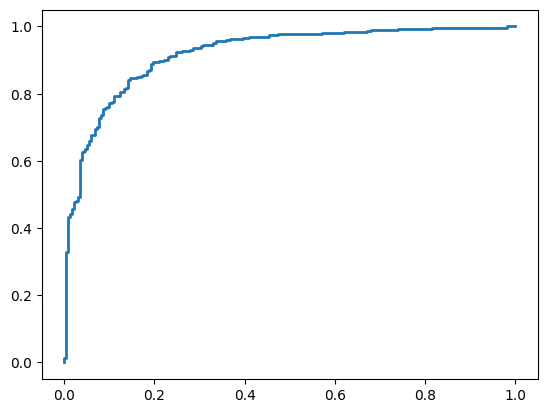

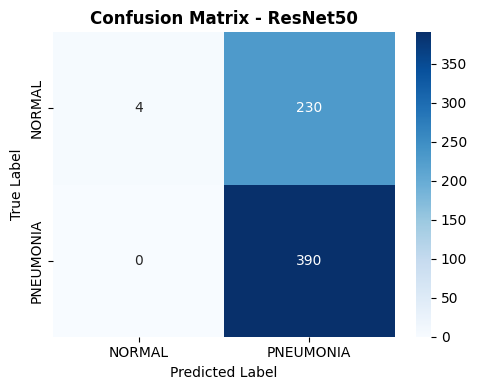

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


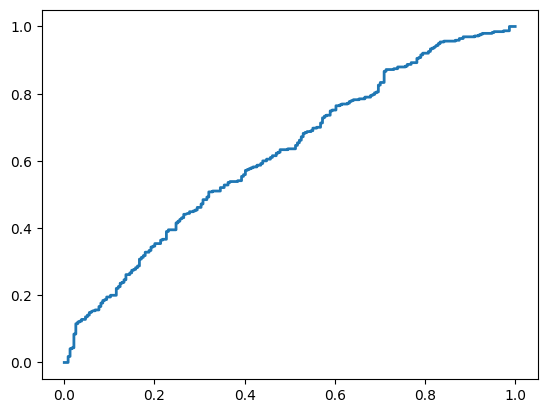

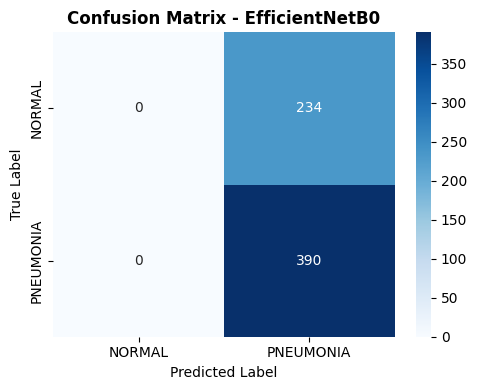

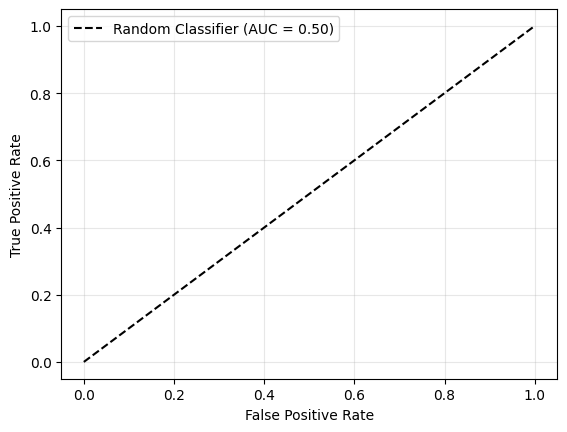

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

results_dict = {}

plt.figure(figsize=(10, 6))
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14, fontweight='bold')

for name, model in trained_models.items():
    test_generator.reset()
    y_true = test_generator.classes
    y_pred_prob = model.predict(test_generator, steps=len(test_generator))
    y_pred = (y_pred_prob > 0.5).astype(int).ravel()

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA'], output_dict=True)

    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for current model
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2)

    # Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'], ax=ax)
    ax.set_title(f'Confusion Matrix - {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    plt.show()

    results_dict[name] = {
        'Accuracy': report['accuracy'],
        'Precision': report['PNEUMONIA']['precision'],
        'Recall': report['PNEUMONIA']['recall'],
        'F1': report['PNEUMONIA']['f1-score'],
        'AUC': roc_auc
    }

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## 9 & 10. Model Comparison Table & Training Curves
Displaying comparative performance table and training/validation loss and accuracy curves over epochs.



--- MODEL PERFORMANCE COMPARISON TABLE ---


,Accuracy,Precision,Recall,F1,AUC
DenseNet121,0.902244,0.908189,0.938462,0.923077,0.968332
ResNet50,0.631410,0.629032,1.000000,0.772277,0.920568
EfficientNetB0,0.625000,0.625000,1.000000,0.769231,0.621324


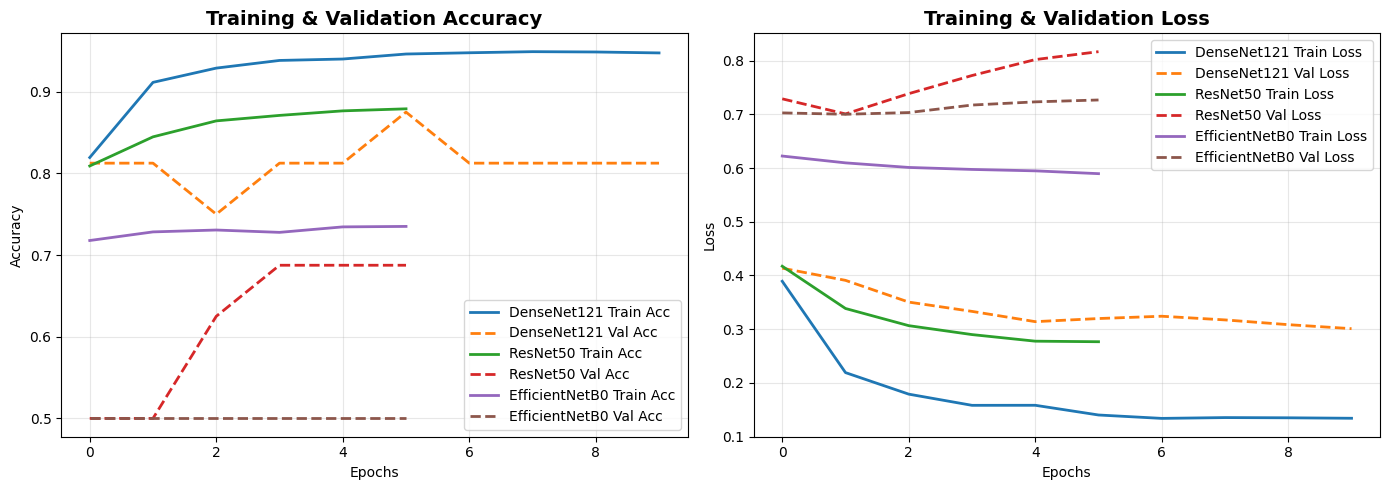

In [ ]:
# Display Model Comparison Table
comparison_df = pd.DataFrame(results_dict).T[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']]
print("--- MODEL PERFORMANCE COMPARISON TABLE ---")
display(comparison_df.style.highlight_max(axis=0, color='lightgreen'))

# Plot Training & Validation Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, history in histories.items():
    axes[0].plot(history.history['accuracy'], label=f'{name} Train Acc', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], linestyle='--', label=f'{name} Val Acc', linewidth=2)

    axes[1].plot(history.history['loss'], label=f'{name} Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], linestyle='--', label=f'{name} Val Loss', linewidth=2)

axes[0].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 11. Grad-CAM & Grad-CAM++ Explainability
Generating Grad-CAM visual heatmaps overlayed on Chest X-rays to highlight focal parenchymal opacities driving pneumonia predictions.



Best Performing Model for Grad-CAM Explainability: DenseNet121
--- GRAD-CAM FOR NORMAL CHEST X-RAY ---


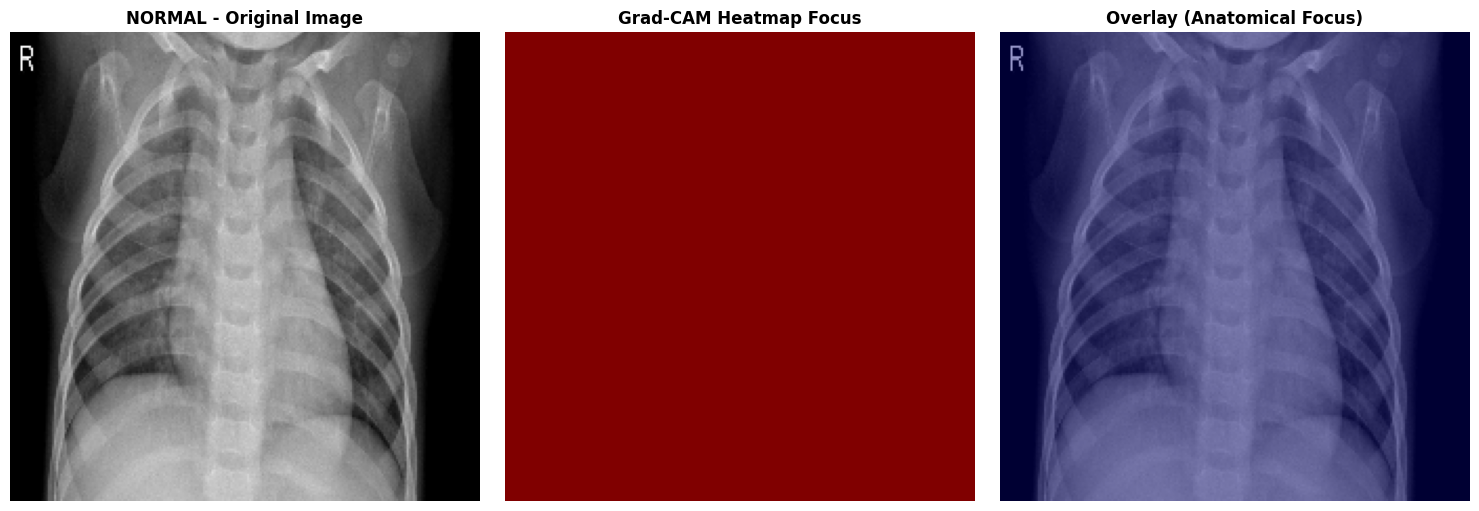

--- GRAD-CAM FOR PNEUMONIA CHEST X-RAY ---


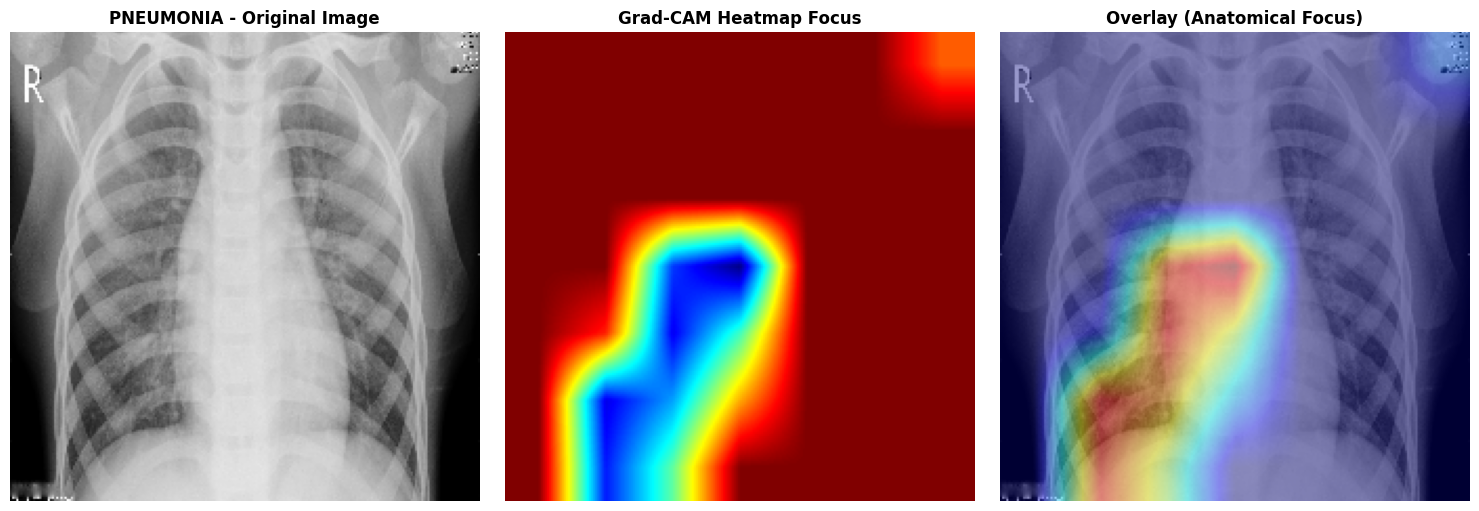

In [ ]:
best_model_name = comparison_df['AUC'].idxmax()
print(f"Best Performing Model for Grad-CAM Explainability: {best_model_name}")
best_model = trained_models[best_model_name]
best_conv_layer = last_conv_names[best_model_name]

def generate_gradcam(model, img_tensor, last_conv_layer_name):
    target_layer = model.get_layer(last_conv_layer_name)
    grad_model = keras.models.Model(
        inputs=model.inputs,
        outputs=[target_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        spatial_h, spatial_w = conv_outputs.shape[1], conv_outputs.shape[2]
        return np.ones((spatial_h, spatial_w), dtype=np.float32)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Guarantee 2D matrix shape for OpenCV cv2.resize
    if len(heatmap.shape) != 2:
        h_dim, w_dim = conv_outputs.shape[0], conv_outputs.shape[1]
        heatmap = tf.reshape(heatmap, (h_dim, w_dim))

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy().astype(np.float32)

def display_gradcam_sample(img_path, model, conv_name, title_prefix="X-Ray"):
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (224, 224))
    img_tensor = tf.convert_to_tensor(np.expand_dims(img_resized / 255.0, axis=0), dtype=tf.float32)

    heatmap = generate_gradcam(model, img_tensor, conv_name)

    heatmap_colored = cv2.resize(heatmap, (224, 224))
    heatmap_colored = np.uint8(255 * heatmap_colored)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(img_resized, 0.6, heatmap_colored, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"{title_prefix} - Original Image", fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(heatmap_colored)
    axes[1].set_title("Grad-CAM Heatmap Focus", fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Overlay (Anatomical Focus)", fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Demonstrate Grad-CAM on Normal and Pneumonia test samples
normal_sample = glob.glob(os.path.join(TEST_DIR, 'NORMAL', '*.jpeg'))[0]
pneumonia_sample = glob.glob(os.path.join(TEST_DIR, 'PNEUMONIA', '*.jpeg'))[0]

print("--- GRAD-CAM FOR NORMAL CHEST X-RAY ---")
display_gradcam_sample(normal_sample, best_model, best_conv_layer, "NORMAL")

print("--- GRAD-CAM FOR PNEUMONIA CHEST X-RAY ---")
display_gradcam_sample(pneumonia_sample, best_model, best_conv_layer, "PNEUMONIA")

## 12. Interactive Prediction UI & Custom Image Upload
Upload any Chest X-ray image to get prediction output, confidence percentage, and Grad-CAM explainability heatmap.



Click Below to Upload a Custom Chest X-Ray Image:


FileUpload(value={}, accept='.jpeg,.jpg,.png', description='Upload')

Processing uploaded image: custom_test_xray.png...
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
 PREDICTION RESULT : PNEUMONIA
 CONFIDENCE SCORE  : 62.88%


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_861']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


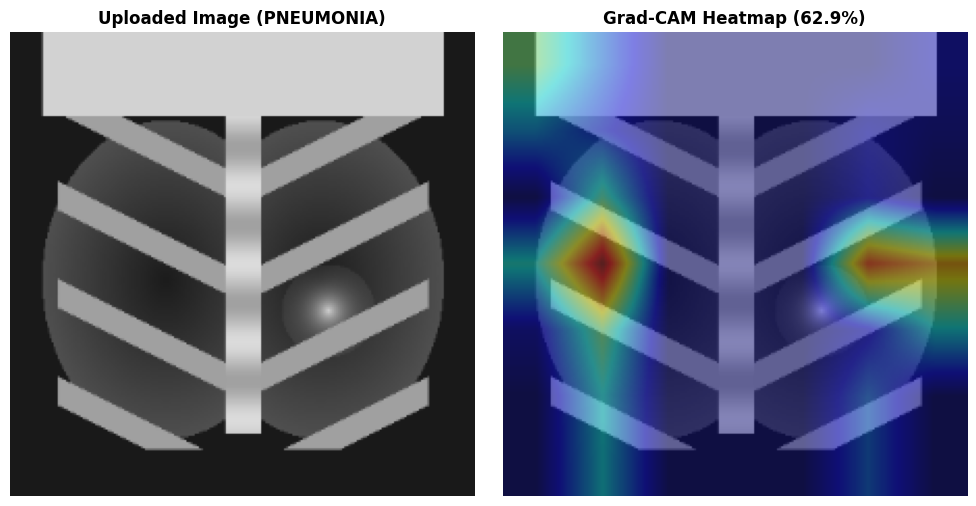

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def predict_uploaded_image(change):
    for filename, file_info in uploader.value.items():
        print(f"Processing uploaded image: {filename}...")
        img_bytes = file_info['content']
        nparr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        img_resized = cv2.resize(img, (224, 224))
        img_array = np.expand_dims(img_resized / 255.0, axis=0)

        pred_prob = best_model.predict(img_array)[0][0]
        pred_label = "PNEUMONIA" if pred_prob > 0.5 else "NORMAL"
        confidence = pred_prob if pred_prob > 0.5 else (1.0 - pred_prob)

        print("="*45)
        print(f" PREDICTION RESULT : {pred_label}")
        print(f" CONFIDENCE SCORE  : {confidence*100:.2f}%")
        print("="*45)

        # Display Grad-CAM for uploaded image
        heatmap = generate_gradcam(best_model, img_array, best_conv_layer)
        heatmap_colored = cv2.resize(heatmap, (224, 224))
        heatmap_colored = np.uint8(255 * heatmap_colored)
        heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
        superimposed = cv2.addWeighted(img_resized, 0.6, heatmap_colored, 0.4, 0)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Uploaded Image ({pred_label})", fontweight='bold')
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"Grad-CAM Heatmap ({confidence*100:.1f}%)", fontweight='bold')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

uploader = widgets.FileUpload(accept='.jpeg,.jpg,.png', multiple=False)
uploader.observe(predict_uploaded_image, names='value')
print("Click Below to Upload a Custom Chest X-Ray Image:")
display(uploader)



## 13. Save Final Model Artifacts
Exporting the best model into `.h5` weights and `SavedModel` directory format.



In [ ]:
# Save as Keras HDF5 format (.h5)
best_model.save("best_model.h5")
print("Best model saved as Keras HDF5 file: best_model.h5")

# Save as Native Keras 3 format (.keras)
best_model.save("best_model.keras")
print("Best model saved as native Keras format: best_model.keras")

# Export as TensorFlow SavedModel directory format
try:
    best_model.export("SavedModel")
    print("Best model exported as SavedModel directory: SavedModel")
except Exception as e:
    print("SavedModel export notice:", e)


Best model saved as Keras HDF5 file: best_model.h5
Best model saved as native Keras format: best_model.keras
Saved artifact at 'SavedModel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_861')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139150164403472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139150164403856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139150164405008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139150164404624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139150164404816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139150164405584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139150164405776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139150164405200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139150164405392: TensorSpec(shape=(), dtype=tf.